**@author: Mano Joseph MATHEW**
**@student: HuZicong**
**@group: WUT_Nov2025**
**@email: mano.mathew@efrei.fr**
**Introduction**
The goals for this session are multiple: Use the Jupyter computing environment, that is a widely used tool to develop and share data analysis and data visualization workflows.
**Understanding the basic techniques**
- Loading CSV Uber Data file
- Data transformation
- Create Functions
- Use matplotlib, pandas, seaborn
- Use a simple plot for ploting Uber longitute and latitude data
**Load the data**
Download the data "uber-raw-data-apr14.csv"
Use pandas.read_csv to read the csv file
**Perform Data transformation**
- Use .pd.to_datetime for better date transformation
- Creating a function for finding the day of the month example: def get_dom(dt): return dt.day data['dom'] = data['Date/Time'].map(get_dom)
- Creating a function for finding the weekday and hours example: def get_weekday(dt): return dt.weekday() data['weekday']= data['Date/Time'].map(get_weekday)
- Analyse the day of month
**Visual representation**
- Use hist for creating histogram with bins = 30, rwidth=0.8, range=(0.5,30.5)
- Label the title as Frequency by DoM - Uber - April 2014, x-axis Date of the month and y-axis Frequency
- Creating a function for Grouping the data by date of month (dom) example: def count_rows(rows): return len(rows)
- Use plot, bar function to plot the data by date
- Sort the data by date and use bar function to plot the sorted data by date (.sort_values())
- Visualise the data by hours using histogram with bins=24,range=(0.5,24)
- Visualise the data by weekday using histogram with bins=7,range = (-.5,6.5), rwidth=0.8
- Check the use of xticks and add 'Mon Tue Wed Thu Fri Sat Sun'.split()
**Performing Cross Analysis**
- Group the data by weekday and hour using .apply(count_rows).unstack()
- Create heatmap using seaborn.heatmap for the grouped data
- Analyse both Latitude and Longitude data represent the specific ranges for each respectively
- Example Latitude range =(40.5,41) and likewise set for Longitude
- Merge the two histograms Latitude and Longitude using twiny()
- Plot the dots for both Latitude and Longitude set the figsize=(20, 20)
**“By visualizing information, we turn it into a landscape that you can explore with your eyes. A sort of information map. And when you’re lost in information

In [1]:
#Installing the necessary libraries
!pip install pandas numpy matplotlib seaborn

In [2]:
#Importing libraries to the local environment and create abbrevations for easier usageimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = "uber-raw-data-apr14.csv" #reading the csv file : Note that you have downloaded the csv file to the location

In [4]:
import pandas as pd
df = pd.read_csv(path, delimiter = ',') #Using delimiter for identifying the different columns

In [5]:
df

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
...,...,...,...,...
564511,4/30/2014 23:22:00,40.7640,-73.9744,B02764
564512,4/30/2014 23:26:00,40.7629,-73.9672,B02764
564513,4/30/2014 23:31:00,40.7443,-73.9889,B02764
564514,4/30/2014 23:32:00,40.6756,-73.9405,B02764


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [7]:
df['Date/Time'] = pd.to_datetime(df['Date/Time']) #Note : It takes time depending on your machines memory

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date/Time  564516 non-null  datetime64[ns]
 1   Lat        564516 non-null  float64       
 2   Lon        564516 non-null  float64       
 3   Base       564516 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 17.2+ MB


In [9]:
# Creating a function for finding the day of the month example: def get_dom(dt): return dt.day data['dom'] = data['Date/Time'].map(get_dom)

In [10]:
def get_dom(dt):
    return dt.day #.day is an attribute

In [11]:
df['day'] = df['Date/Time'].map(get_dom)

In [12]:
df

,Date/Time,Lat,Lon,Base,day
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,1
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,1
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,1
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,1
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,1
...,...,...,...,...,...
564511,2014-04-30 23:22:00,40.7640,-73.9744,B02764,30
564512,2014-04-30 23:26:00,40.7629,-73.9672,B02764,30
564513,2014-04-30 23:31:00,40.7443,-73.9889,B02764,30
564514,2014-04-30 23:32:00,40.6756,-73.9405,B02764,30


In [13]:
def get_weekday(dt):
    return dt.weekday() #.weekday() is a method

In [14]:
df['weekday'] = df['Date/Time'].map(get_weekday)

In [15]:
df

,Date/Time,Lat,Lon,Base,day,weekday
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,1,1
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,1,1
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,1,1
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,1,1
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,1,1
...,...,...,...,...,...,...
564511,2014-04-30 23:22:00,40.7640,-73.9744,B02764,30,2
564512,2014-04-30 23:26:00,40.7629,-73.9672,B02764,30,2
564513,2014-04-30 23:31:00,40.7443,-73.9889,B02764,30,2
564514,2014-04-30 23:32:00,40.6756,-73.9405,B02764,30,2


# Let us start Visual representation
 

# Create histogram to know the Frequency by Days of the month

Text(0.5, 0, 'Days of the month')

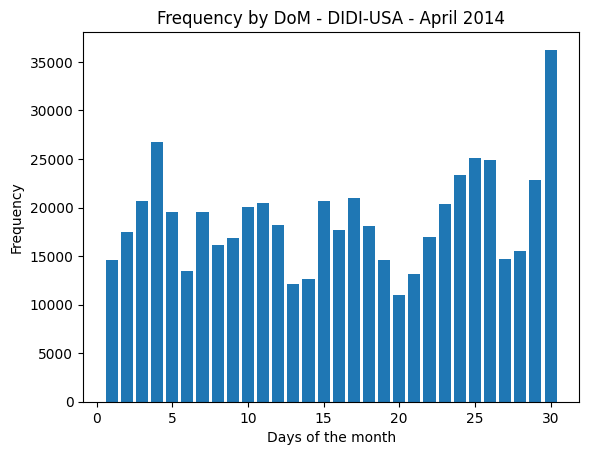

In [16]:
hist = df["day"].plot.hist(bins = 30, rwidth = 0.8, range=(0.5,30.5), title = "Frequency by DoM - DIDI-USA - April 2014")
plt.xlabel('Days of the month')
#binsint or sequence or str, default: rcParams["hist.bins"] (default: 10)
#If bins is an integer, it defines the number of equal-width bins in the range.
#If bins is a sequence, it defines the bin edges, including the left edge of the first bin
#and the right edge of the last bin; in this case, bins may be unequally spaced.
 

# Creating a function for Grouping the data by date of month (dom) example: def count_rows(rows): return len(rows)

In [17]:
def count_rows(rows):
    return len(rows)

In [18]:
by_date = df.groupby('day').apply(count_rows)
by_date

C:\Users\10385\AppData\Local\Temp\ipykernel_49880\1814074559.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_date = df.groupby('day').apply(count_rows)


day
1     14546
2     17474
3     20701
4     26714
5     19521
6     13445
7     19550
8     16188
9     16843
10    20041
11    20420
12    18170
13    12112
14    12674
15    20641
16    17717
17    20973
18    18074
19    14602
20    11017
21    13162
22    16975
23    20346
24    23352
25    25095
26    24925
27    14677
28    15475
29    22835
30    36251
dtype: int64

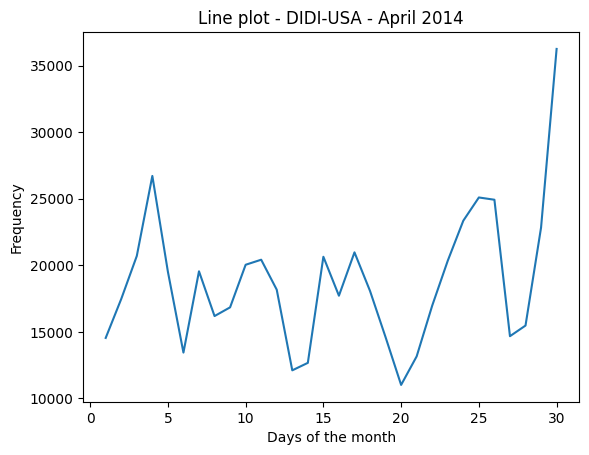

In [19]:
plt.title('Line plot - DIDI-USA - April 2014')
plt.xlabel('Days of the month')
plt.ylabel('Frequency')
plt.plot(by_date);

# Use the plot and bar functions to plot data by date Sort the data by date and use the bar function to plot the data sorted by date (.sort_values())

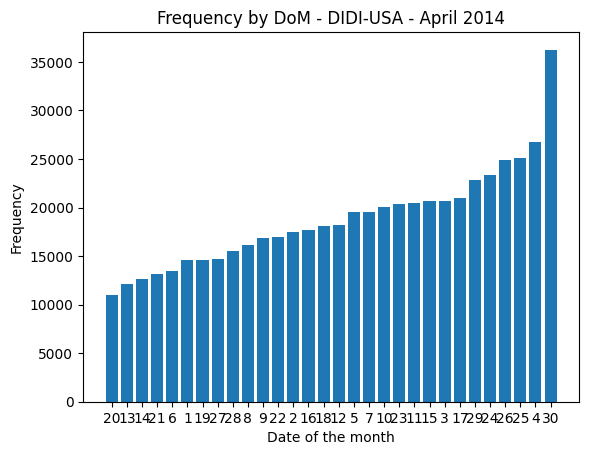

In [20]:
plt.bar(range(1, 31), by_date.sort_values())
plt.xticks(range(1, 31), by_date.sort_values().index)
plt.xlabel('Date of the month')
plt.ylabel('Frequency')
plt.title('Frequency by DoM - DIDI-USA - April 2014');

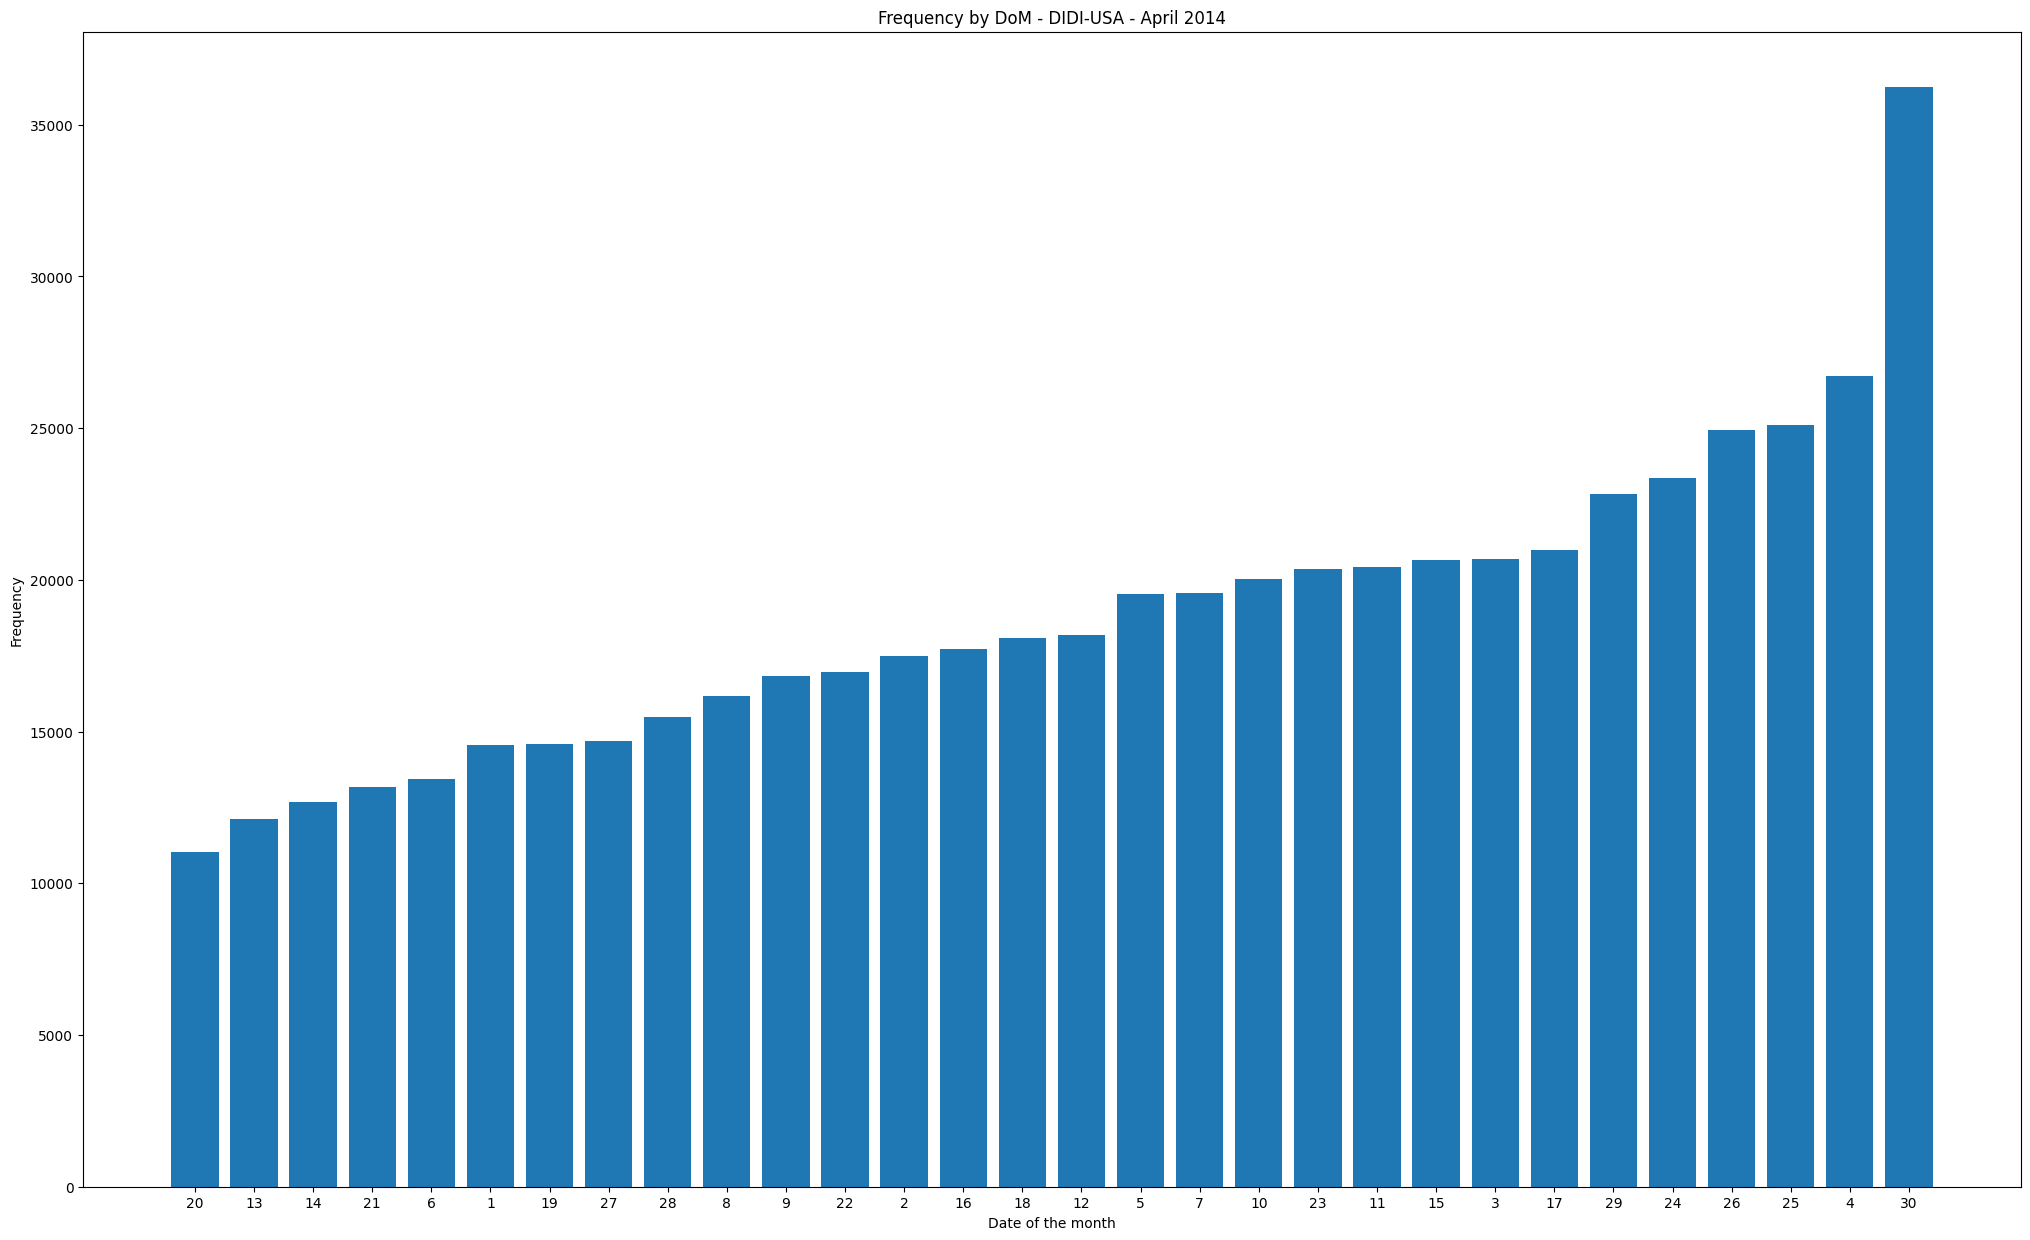

In [21]:
plt.figure(figsize = (25, 15))
plt.bar(range(1, 31), by_date.sort_values())
plt.xticks(range(1, 31), by_date.sort_values().index)
plt.xlabel('Date of the month')
plt.ylabel('Frequency')
plt.title('Frequency by DoM - DIDI-USA - April 2014');

# Visualise data by hour using a histogram with bins=24, range=(0.5,24)

In [22]:
def get_hour(dt):
    return dt.hour
df['hour'] = df['Date/Time'].map(get_hour)

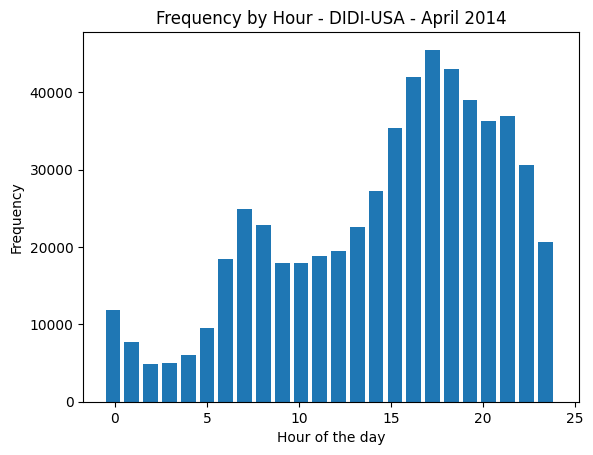

In [23]:
plt.hist(df.hour, bins = 24, range = (-0.5, 24), width = 0.8)
plt.xlabel('Hour of the day')
plt.ylabel('Frequency')
plt.title('Frequency by Hour - DIDI-USA - April 2014');

# Visualise the data by weekday using histogram with bins=7,range = (-.5,6.5), rwidth=0.8

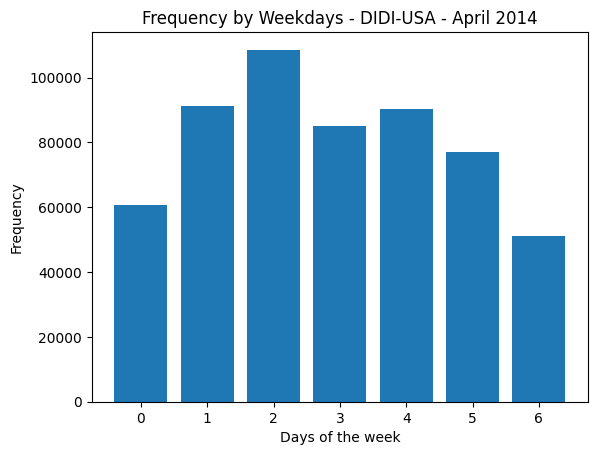

In [24]:
plt.hist(df.weekday, bins = 7, rwidth = 0.8, range = (-.5, 6.5))
plt.xlabel('Days of the week')
plt.ylabel('Frequency')
plt.title('Frequency by Weekdays - DIDI-USA - April 2014');

# Check the use of xticks and add 'Mon Tue Wed Thu Fri Sat Sun'.split()

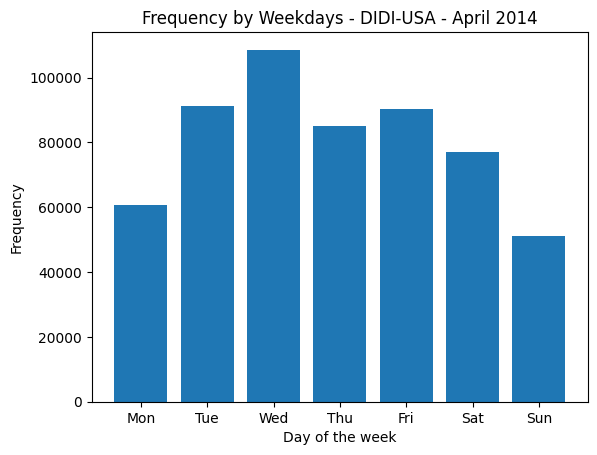

In [25]:
plt.hist(df.weekday, bins = 7, rwidth = 0.8, range = (-.5, 6.5))
plt.xlabel('Day of the week')
plt.ylabel('Frequency')
plt.title('Frequency by Weekdays - DIDI-USA - April 2014')
plt.xticks(np.arange(7), 'Mon Tue Wed Thu Fri Sat Sun'.split())
plt.show()

# Performing Cross Analysis
 
- Group the data by weekday and hour using .apply(count_rows).unstack()

In [26]:
df2 = df.groupby(['weekday', 'hour']).size().unstack()
df2.head()
#Pandas Unstack is a function that pivots the level of the indexed columns in a stacked dataframe. 
#A stacked dataframe is usually a result of an aggregated groupby function in pandas.
#Stack() sets the columns to a new level of hierarchy whereas Unstack() pivots the indexed column.

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,518,261,238,571,1021,1619,2974,3888,3138,2211,...,3117,3818,4962,5574,4725,4386,3573,3079,1976,1091
1,765,367,304,516,887,1734,3766,5304,4594,2962,...,4489,6042,7521,8297,7089,6459,6310,5993,3614,1948
2,899,507,371,585,1003,1990,4230,5647,5242,3846,...,5438,7071,8213,9151,8334,7794,7783,6921,4845,2571
3,792,459,342,567,861,1454,3179,4159,3616,2654,...,4083,5182,6149,6951,6637,5929,6345,6585,5370,2909
4,1367,760,513,736,932,1382,2836,3943,3648,2732,...,4087,5354,6259,6790,7258,6247,5165,6265,6708,5393


# Create heatmap using seaborn.heatmap for the grouped data

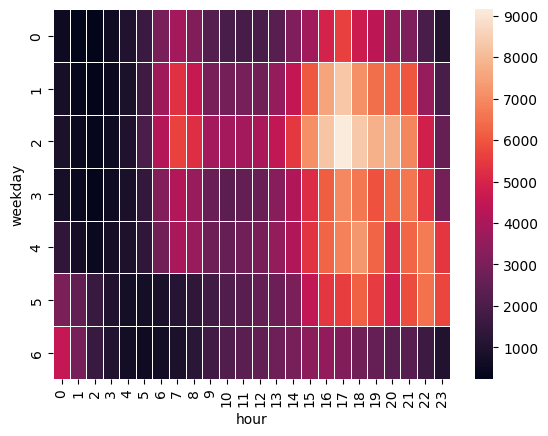

In [27]:
sns.heatmap(df2, linewidths = .5);

# Adding annotation to the weekdays for better understanding

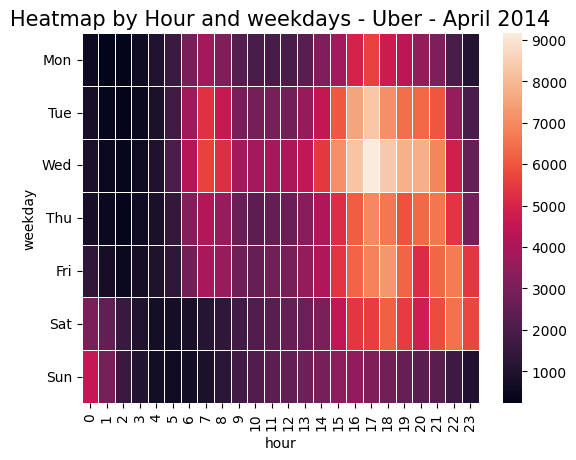

In [28]:
heatmap = sns.heatmap(df2, linewidths = .5);
#Annoted heatmap
plt.title('Heatmap by Hour and weekdays - Uber - April 2014',fontsize=15)
heatmap.set_yticklabels(('Mon Tue Wed Thu Fri Sat Sun').split(), rotation='horizontal');

# Analyse both Latitude and Longitude data represent the specific ranges for each respectively
 

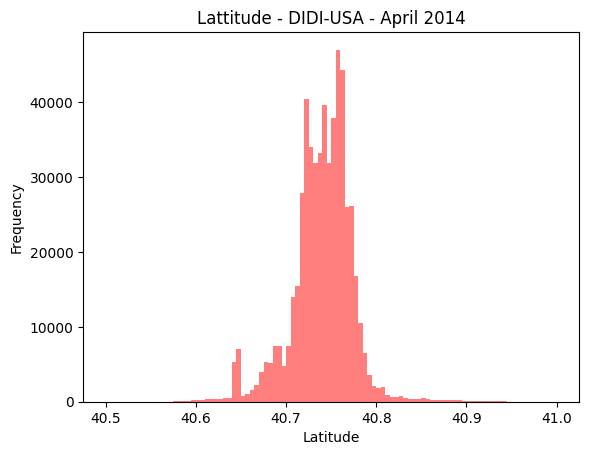

In [29]:
#Lat :
plt.hist(df['Lat'], bins = 100, range = (40.5, 41), color = 'r',alpha = 0.5, label = 'Latitude')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Lattitude - DIDI-USA - April 2014');
plt.show()

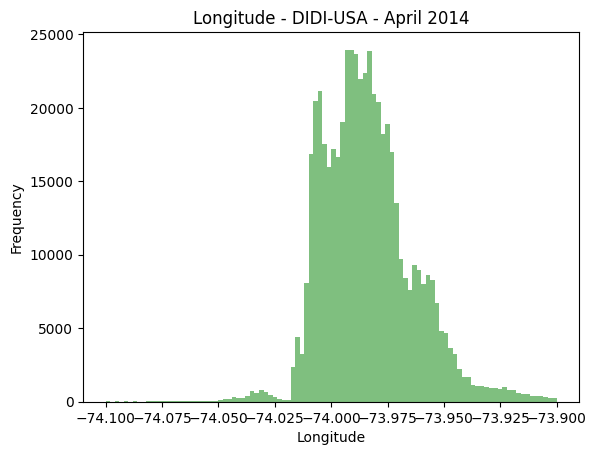

In [30]:
#Lon :
plt.hist(df['Lon'], bins = 100, range = (-74.1, -73.9), color = 'g', alpha = 0.5, label = 'Longitude')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.title('Longitude - DIDI-USA - April 2014');
plt.show()

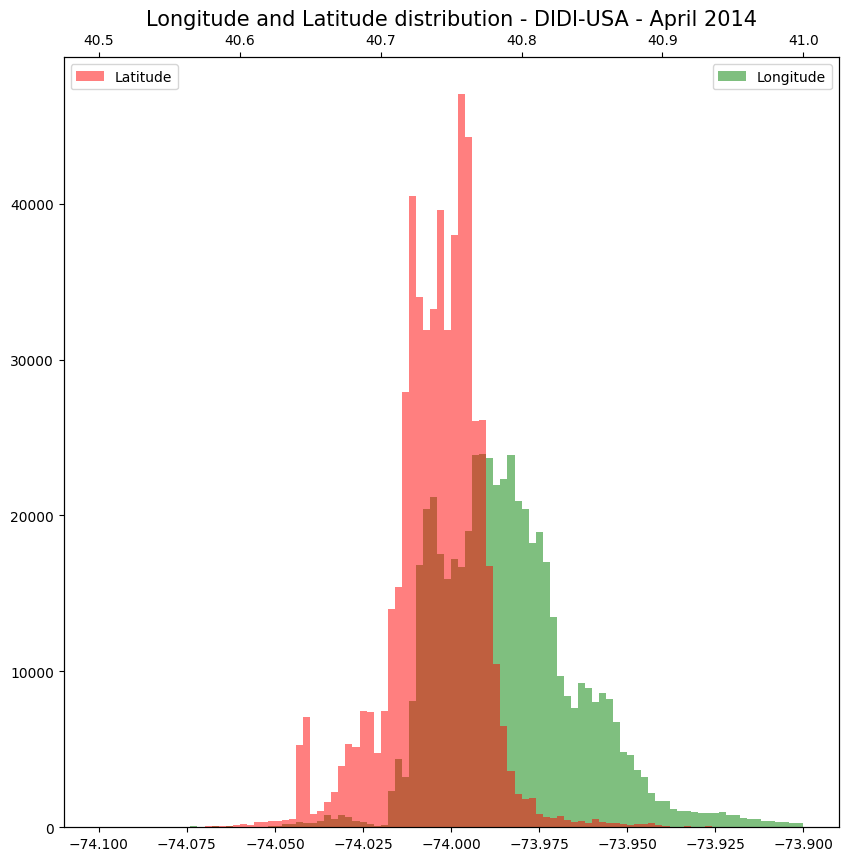

In [31]:
# Let's use the twiny() function to overlay the two images with an opacity of 0.5
plt.figure(figsize=(10, 10), dpi=100)
plt.title('Longitude and Latitude distribution - DIDI-USA - April 2014',fontsize=15)
plt.hist(df['Lon'], bins = 100, range = (-74.1, -73.9), color = 'g', alpha = 0.5, label = 'Longitude')
plt.legend(loc = 'best')
plt.twiny()
plt.hist(df['Lat'], bins = 100, range = (40.5, 41), color = 'r',alpha = 0.5, label = 'Latitude')
plt.legend(loc = 'upper left')
plt.show()

''

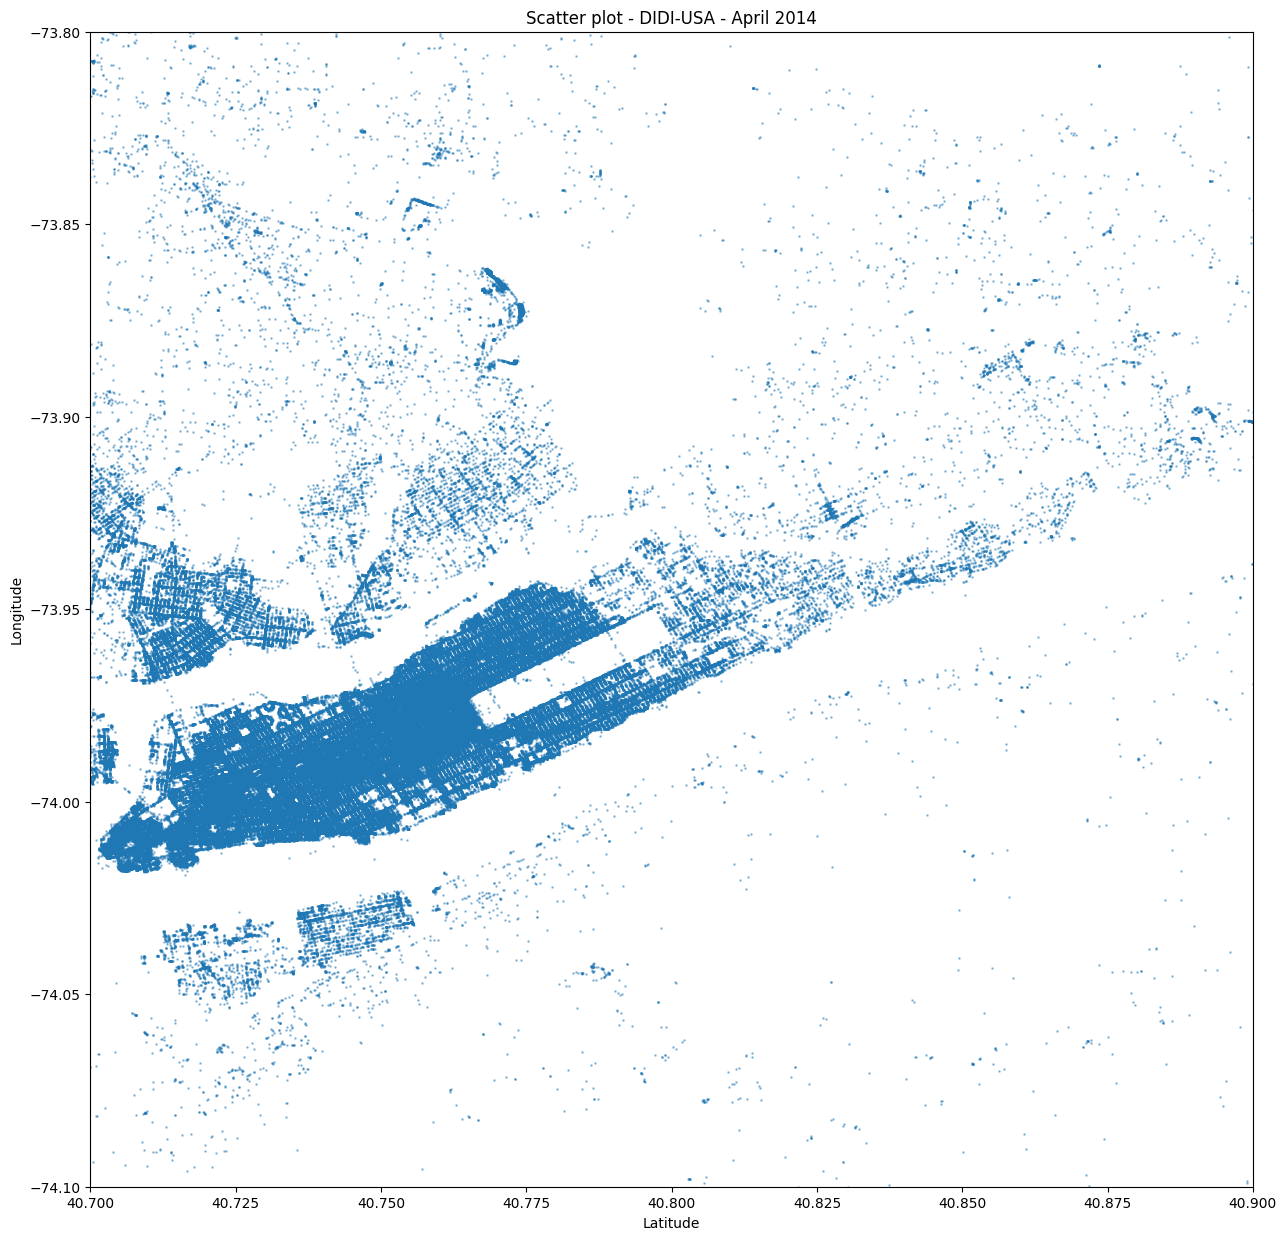

In [32]:
plt.figure(figsize=(15, 15), dpi=100)
plt.title('Scatter plot - DIDI-USA - April 2014')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.scatter(df['Lat'],df['Lon'],s=0.8,alpha=0.4) #Without list also shows the same plot
plt.ylim(-74.1, -73.8)
plt.xlim(40.7, 40.9)
;

# Dataset2 to be done by students

Explore with the second dataset and try to explore in the similar fashion or try other libraries accordingly to your interest

In [33]:
path2 = "https://raw.githubusercontent.com/uber-web/kepler.gl-data/master/nyctrips/data.csv"
d2 = pd.read_csv(path2, delimiter = ',')

In [34]:
d2

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,tip_amount,total_amount
0,2,2015-01-15 19:05:39 +00:00,2015-01-15 19:23:42 +00:00,1,1.59,-73.993896,40.750111,-73.974785,40.750618,12.0,3.25,17.05
1,2,2015-01-15 19:05:39 +00:00,2015-01-15 19:32:00 +00:00,1,2.38,-73.976425,40.739811,-73.983978,40.757889,16.5,4.38,22.68
2,2,2015-01-15 19:05:40 +00:00,2015-01-15 19:21:00 +00:00,5,2.83,-73.968704,40.754246,-73.955124,40.786858,12.5,0.00,14.30
3,2,2015-01-15 19:05:40 +00:00,2015-01-15 19:28:18 +00:00,5,8.33,-73.863060,40.769581,-73.952713,40.785782,26.0,8.08,41.21
4,2,2015-01-15 19:05:41 +00:00,2015-01-15 19:20:36 +00:00,1,2.37,-73.945541,40.779423,-73.980850,40.786083,11.5,0.00,13.30
...,...,...,...,...,...,...,...,...,...,...,...,...
97981,1,2015-01-15 06:04:36 +00:00,2015-01-15 06:09:13 +00:00,1,1.00,-73.973167,40.744244,-73.975433,40.752487,5.5,1.26,7.56
97982,1,2015-01-15 06:04:36 +00:00,2015-01-15 06:43:36 +00:00,1,16.70,-73.965134,40.759991,-73.782372,40.644108,52.0,13.20,66.00
97983,1,2015-01-15 06:04:36 +00:00,2015-01-15 06:17:32 +00:00,1,4.50,-74.015182,40.715755,-73.981285,40.765930,15.5,1.00,17.30
97984,1,2015-01-15 06:04:37 +00:00,2015-01-15 06:09:38 +00:00,1,0.80,-73.971794,40.754051,-73.982391,40.759842,5.5,1.00,7.30


In [35]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97986 entries, 0 to 97985
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               97986 non-null  int64  
 1   tpep_pickup_datetime   97986 non-null  object 
 2   tpep_dropoff_datetime  97986 non-null  object 
 3   passenger_count        97986 non-null  int64  
 4   trip_distance          97986 non-null  float64
 5   pickup_longitude       97986 non-null  float64
 6   pickup_latitude        97986 non-null  float64
 7   dropoff_longitude      97986 non-null  float64
 8   dropoff_latitude       97986 non-null  float64
 9   fare_amount            97986 non-null  float64
 10  tip_amount             97986 non-null  float64
 11  total_amount           97986 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 9.0+ MB


# Check missing value

In [36]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

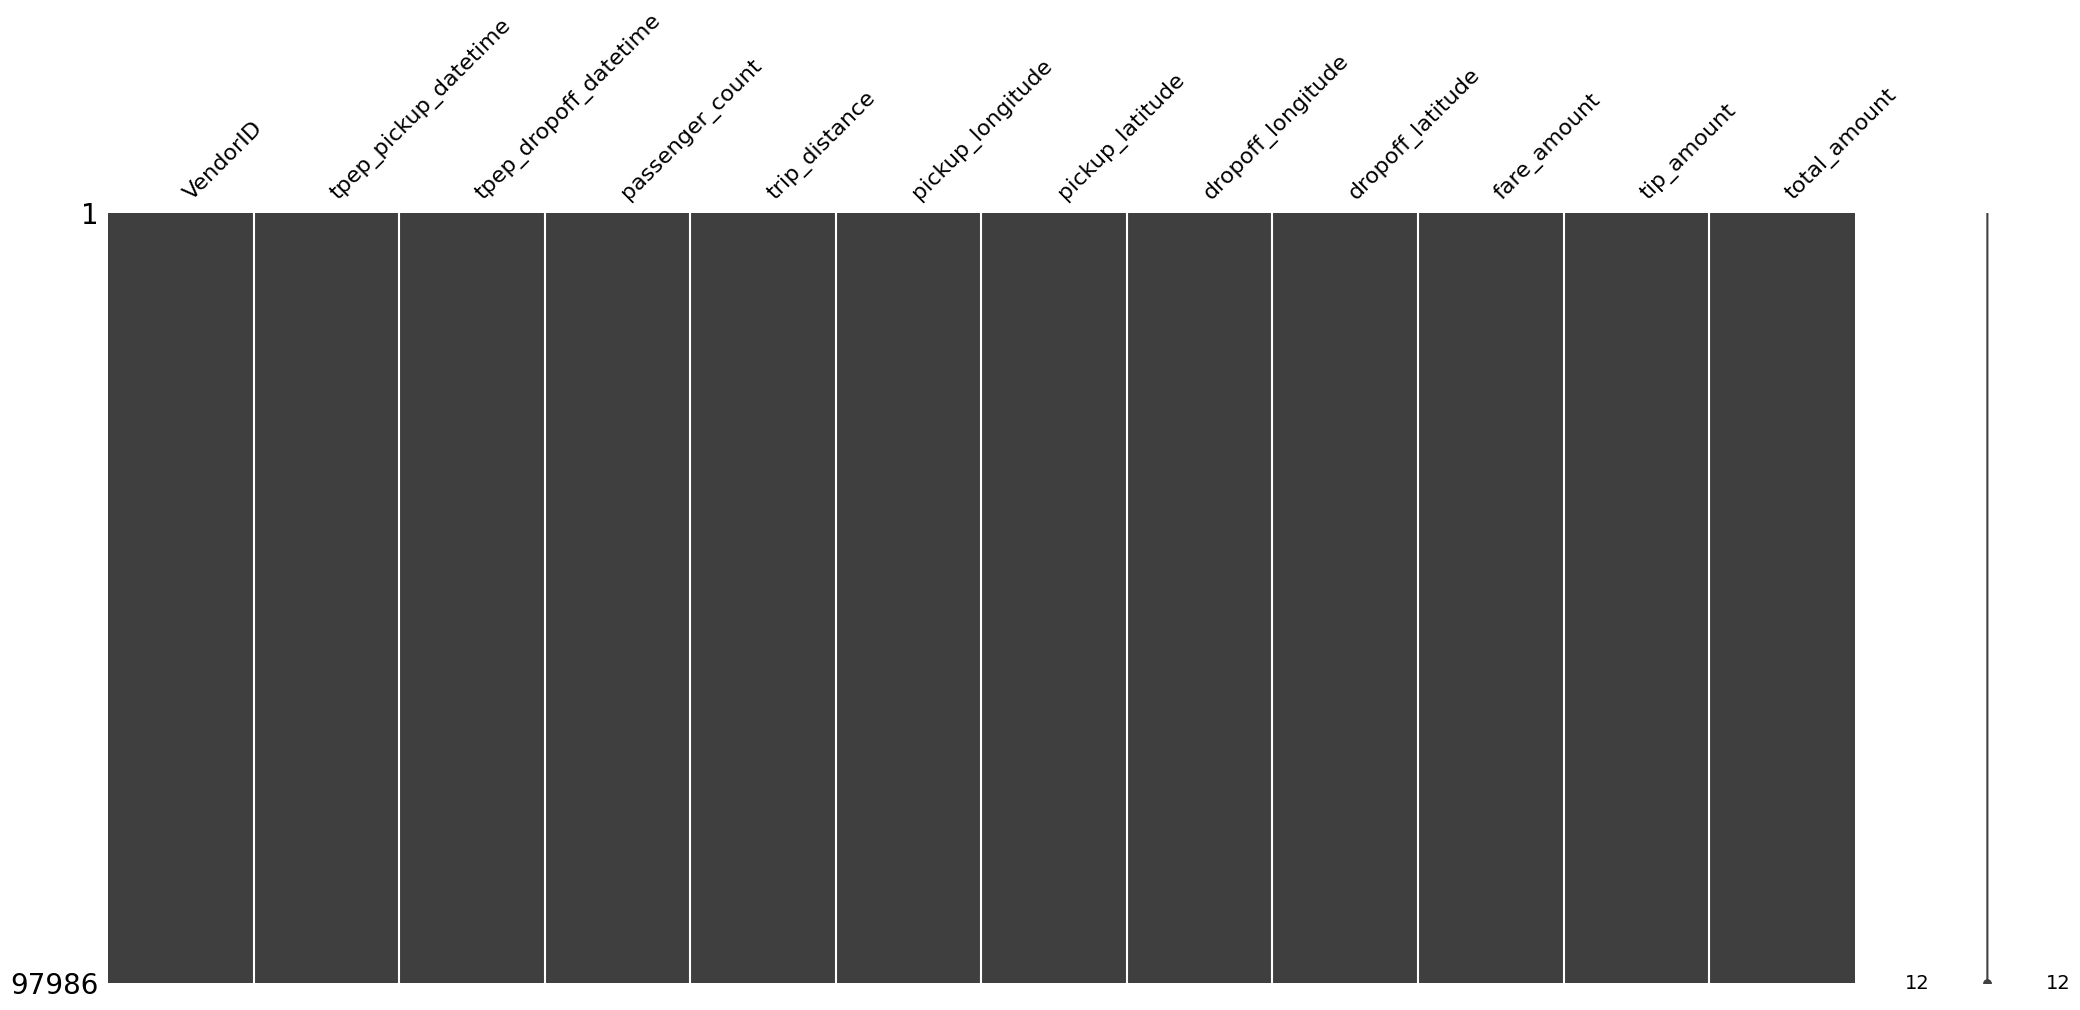

In [37]:
import missingno as msno
%matplotlib inline
msno.matrix(d2.sample(97986))

In [38]:
d2['tpep_dropoff_datetime'] = pd.to_datetime(d2['tpep_dropoff_datetime'])
d2['day'] = d2['tpep_dropoff_datetime'].dt.day

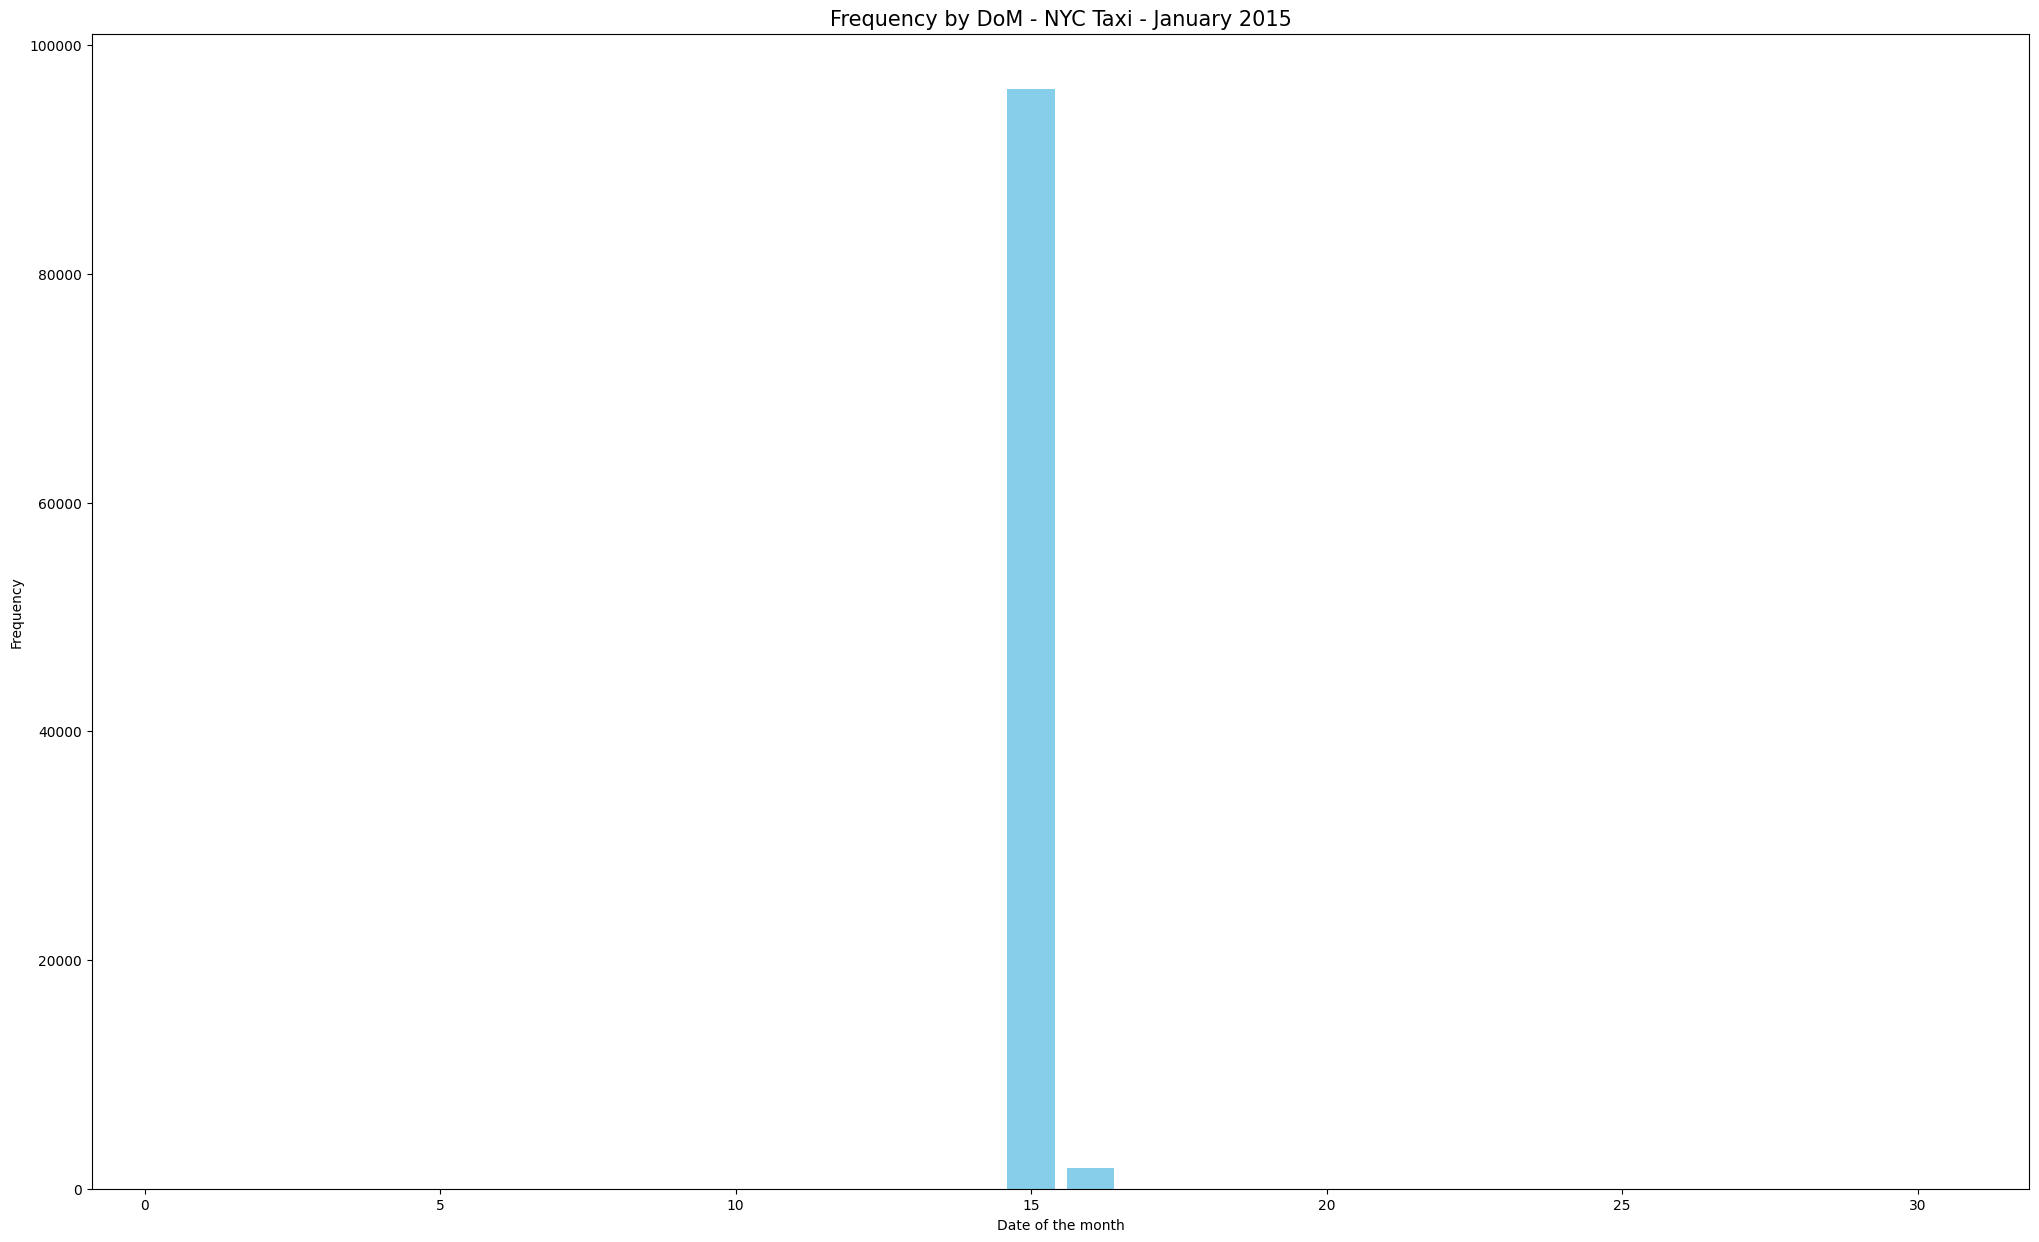

In [56]:
plt.figure(figsize=(25, 15))  # 沿用你习惯的大尺寸
plt.hist(
    d2['day'],  
    bins=30,    
    rwidth=0.8,
    range=(0.5, 30.5),  
    color='skyblue'  
)

plt.xlabel('Date of the month')
plt.ylabel('Frequency')
plt.title('Frequency by DoM - NYC Taxi - January 2015', fontsize=15);

In [68]:
d2['tpep_pickup_datetime'] = pd.to_datetime(d2['tpep_pickup_datetime'])
d2['day'] = d2['tpep_pickup_datetime'].dt.day
d2['weekday'] = d2['tpep_pickup_datetime'].dt.weekday

In [69]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97986 entries, 0 to 97985
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   VendorID               97986 non-null  int64              
 1   tpep_pickup_datetime   97986 non-null  datetime64[ns, UTC]
 2   tpep_dropoff_datetime  97986 non-null  datetime64[ns, UTC]
 3   passenger_count        97986 non-null  int64              
 4   trip_distance          97986 non-null  float64            
 5   pickup_longitude       97986 non-null  float64            
 6   pickup_latitude        97986 non-null  float64            
 7   dropoff_longitude      97986 non-null  float64            
 8   dropoff_latitude       97986 non-null  float64            
 9   fare_amount            97986 non-null  float64            
 10  tip_amount             97986 non-null  float64            
 11  total_amount           97986 non-null  float64        

In [70]:
d2

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,tip_amount,total_amount,day,hour,weekday
0,2,2015-01-15 19:05:39+00:00,2015-01-15 19:23:42+00:00,1,1.59,-73.993896,40.750111,-73.974785,40.750618,12.0,3.25,17.05,15,19,3
1,2,2015-01-15 19:05:39+00:00,2015-01-15 19:32:00+00:00,1,2.38,-73.976425,40.739811,-73.983978,40.757889,16.5,4.38,22.68,15,19,3
2,2,2015-01-15 19:05:40+00:00,2015-01-15 19:21:00+00:00,5,2.83,-73.968704,40.754246,-73.955124,40.786858,12.5,0.00,14.30,15,19,3
3,2,2015-01-15 19:05:40+00:00,2015-01-15 19:28:18+00:00,5,8.33,-73.863060,40.769581,-73.952713,40.785782,26.0,8.08,41.21,15,19,3
4,2,2015-01-15 19:05:41+00:00,2015-01-15 19:20:36+00:00,1,2.37,-73.945541,40.779423,-73.980850,40.786083,11.5,0.00,13.30,15,19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97981,1,2015-01-15 06:04:36+00:00,2015-01-15 06:09:13+00:00,1,1.00,-73.973167,40.744244,-73.975433,40.752487,5.5,1.26,7.56,15,6,3
97982,1,2015-01-15 06:04:36+00:00,2015-01-15 06:43:36+00:00,1,16.70,-73.965134,40.759991,-73.782372,40.644108,52.0,13.20,66.00,15,6,3
97983,1,2015-01-15 06:04:36+00:00,2015-01-15 06:17:32+00:00,1,4.50,-74.015182,40.715755,-73.981285,40.765930,15.5,1.00,17.30,15,6,3
97984,1,2015-01-15 06:04:37+00:00,2015-01-15 06:09:38+00:00,1,0.80,-73.971794,40.754051,-73.982391,40.759842,5.5,1.00,7.30,15,6,3


In [71]:
def get_hour(d2):
    return d2.hour
d2['hour'] = d2['tpep_pickup_datetime'].map(get_hour)

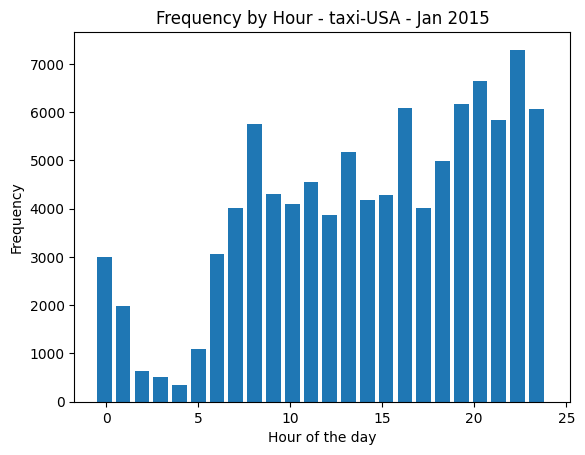

In [72]:
plt.hist(d2.hour, bins = 24, range = (-0.5, 24), width = 0.8)
plt.xlabel('Hour of the day')
plt.ylabel('Frequency')
plt.title('Frequency by Hour - taxi-USA - Jan 2015');

Create heatmap using seaborn.heatmap for the grouped data


In [73]:
by_date = d2.groupby('day').size()

In [74]:
d2_heatmap = d2.groupby(['weekday', 'hour']).size().unstack()

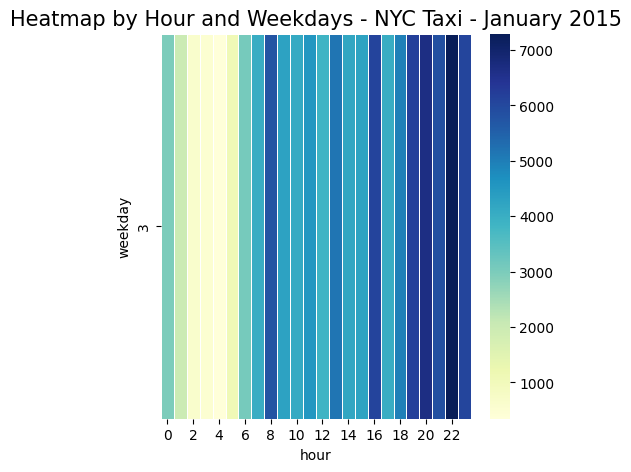

In [75]:
plt.figure(figsize=(5, 5))
heatmap = sns.heatmap(d2_heatmap, linewidths=.5, annot=False, cmap='YlGnBu')
plt.title('Heatmap by Hour and Weekdays - NYC Taxi - January 2015', fontsize=15)
weekday_map = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

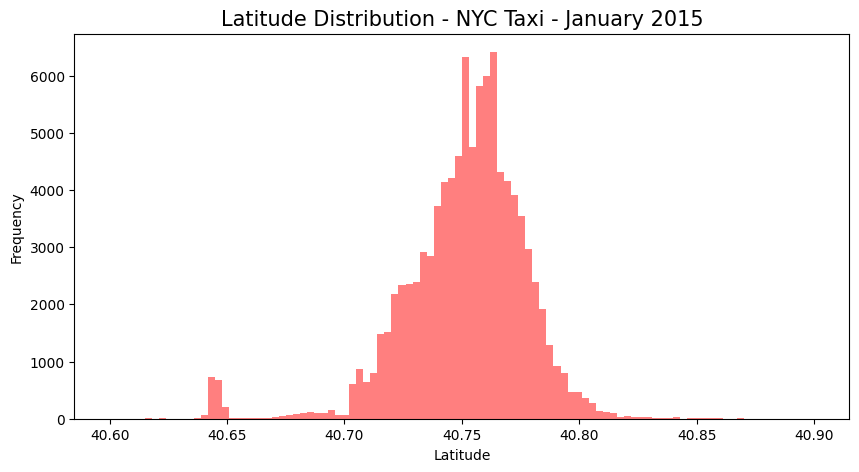

In [76]:
plt.figure(figsize=(10, 5))
plt.hist(d2['pickup_latitude'], bins=100, range=(40.6, 40.9), color='r', alpha=0.5, label='Latitude')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Latitude Distribution - NYC Taxi - January 2015', fontsize=15);

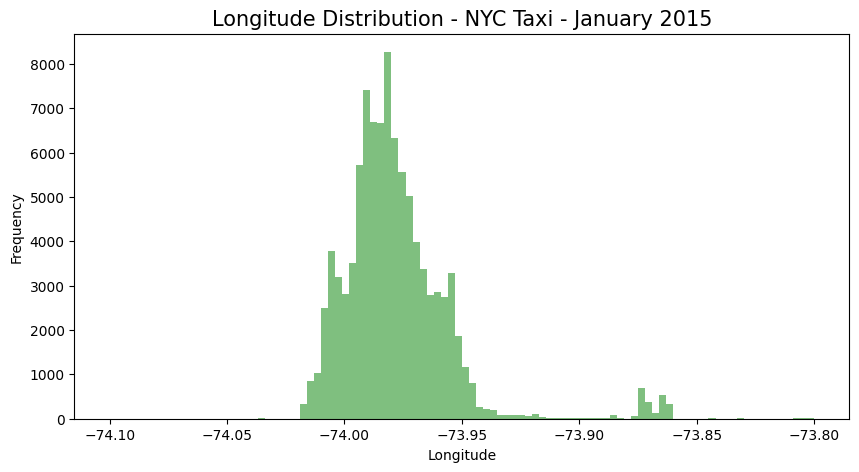

In [77]:
plt.figure(figsize=(10, 5))
plt.hist(d2['pickup_longitude'], bins=100, range=(-74.1, -73.8), color='g', alpha=0.5, label='Longitude')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.title('Longitude Distribution - NYC Taxi - January 2015', fontsize=15);

use the twiny() function to overlay the two images with an opacity of 0.5

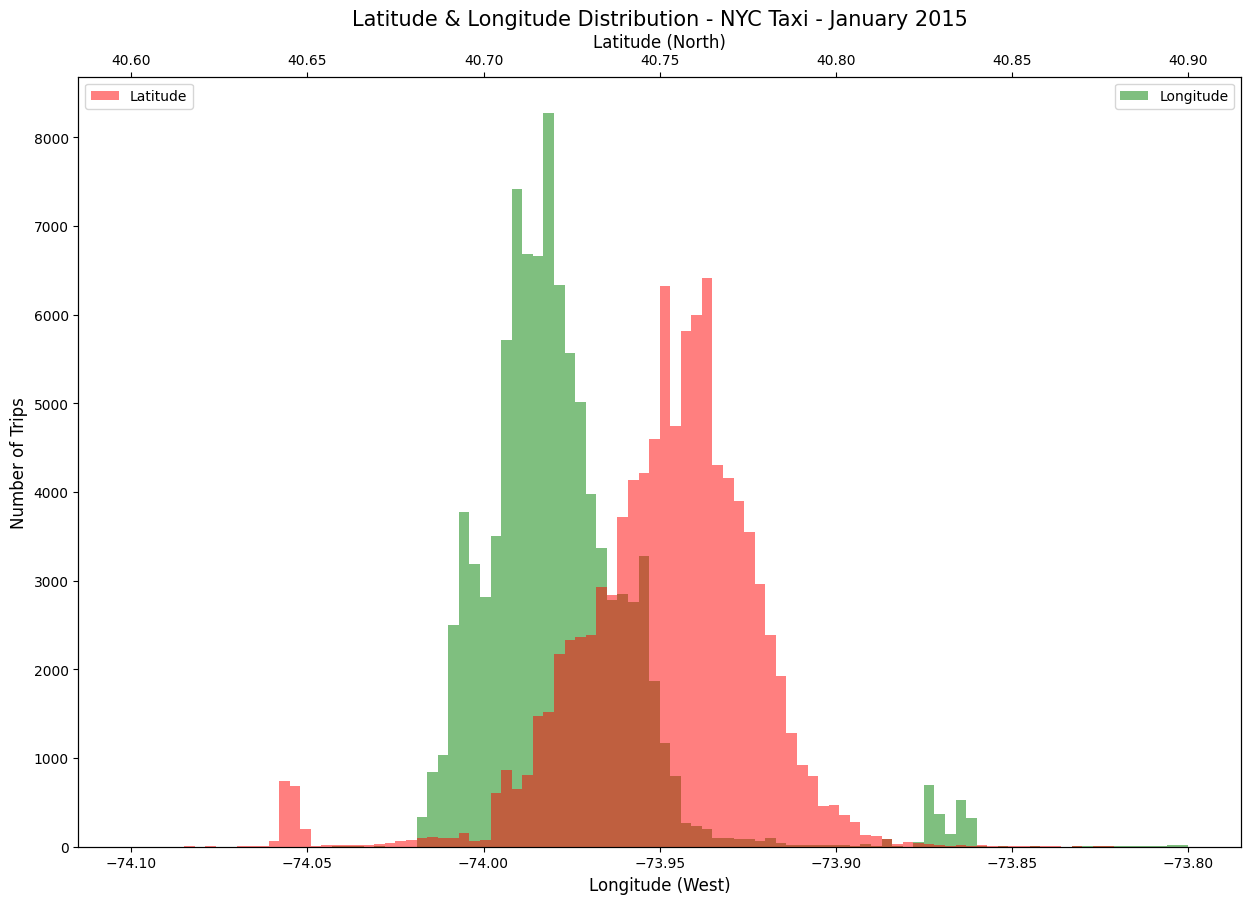

In [78]:
plt.figure(figsize=(15, 10))
plt.hist(d2['pickup_longitude'], bins=100, range=(-74.1, -73.8), color='g', alpha=0.5, label='Longitude')
plt.legend(loc='best')
plt.xlabel('Longitude (West)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
ax2 = plt.twiny()
ax2.hist(d2['pickup_latitude'], bins=100, range=(40.6, 40.9), color='r', alpha=0.5, label='Latitude')
ax2.legend(loc='upper left')
ax2.set_xlabel('Latitude (North)', fontsize=12)
plt.title('Latitude & Longitude Distribution - NYC Taxi - January 2015', fontsize=15);

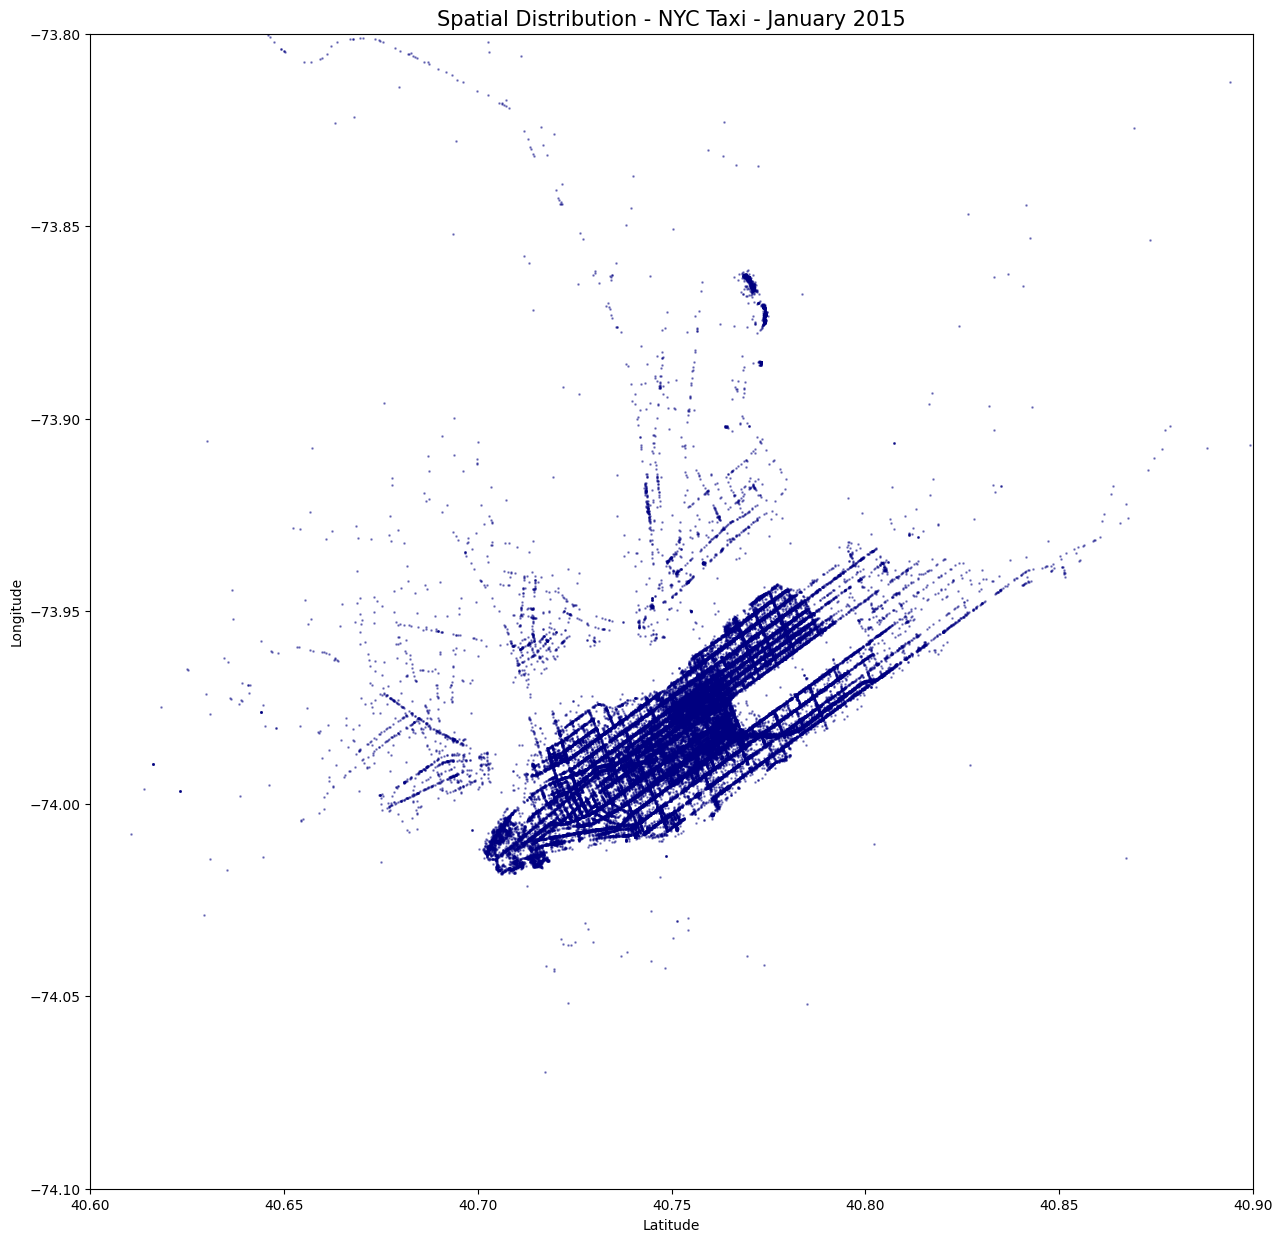

In [79]:
plt.figure(figsize=(15, 15), dpi=100)
plt.title('Spatial Distribution - NYC Taxi - January 2015', fontsize=15)
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.scatter(d2['pickup_latitude'], d2['pickup_longitude'], s=0.8, alpha=0.4, color='navy')
plt.ylim(-74.1, -73.8)
plt.xlim(40.6, 40.9);